In [1]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os
import scipy.io as sio

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

def get_velgradient(cg,pm,pn):
    u1=u2rho_3d(np.squeeze(cg['u'].values))
    v1=v2rho_3d(np.squeeze(cg['v'].values))
    ux=u2rho_3d((u1[:,:,1:]-u1[:,:,:-1])/np.tile(0.5*(1/pm[:,1:]+1/pm[:,:-1]),[u1.shape[0],1,1]))
    vx=u2rho_3d((v1[:,:,1:]-v1[:,:,:-1])/np.tile(0.5*(1/pm[:,1:]+1/pm[:,:-1]),[u1.shape[0],1,1]))
    uy=v2rho_3d((u1[:,1:,:]-u1[:,:-1,:])/np.tile(0.5*(1/pn[1:,:]+1/pn[:-1,:]),[u1.shape[0],1,1]))
    vy=v2rho_3d((v1[:,1:,:]-v1[:,:-1,:])/np.tile(0.5*(1/pn[1:,:]+1/pn[:-1,:]),[u1.shape[0],1,1]))
    return ux,vx,uy,vy

def get_traj(w):
    lon=w['lon'].values
    lat=w['lat'].values
    return lon,lat



In [2]:
data=sio.loadmat('/meddy/simingzhang/Data/Figure_SF3/HIT2d_fk_eps_fitting_plot_for_py.mat')

/home/simingzhang/anaconda3/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


# load variables

In [3]:
cg=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc')
cg

<xarray.Dataset> Size: 14GB
Dimensions:     (time: 199, xi_rho: 512, eta_rho: 512, xi_u: 511, eta_v: 511,
                 depth: 1, depth_2: 1)
Coordinates:
  * time        (time) float64 2kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * xi_rho      (xi_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 509.0 510.0 511.0 512.0
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 510.0 511.0 512.0
  * xi_u        (xi_u) float64 4kB 1.0 2.0 3.0 4.0 ... 508.0 509.0 510.0 511.0
  * eta_v       (eta_v) float64 4kB 1.0 2.0 3.0 4.0 ... 508.0 509.0 510.0 511.0
  * depth       (depth) float64 8B -2.0
Dimensions without coordinates: depth_2
Data variables: (12/71)
    u_rho       (time, depth, eta_rho, xi_rho) float64 417MB ...
    v_rho       (time, depth, eta_rho, xi_rho) float64 417MB ...
    u           (time, depth, eta_rho, xi_u) float64 417MB ...
    v           (time, depth, eta_v, xi_rho) float64 417MB ...
    ocean_time  (time) float64 2kB ...
    lon_rho     (eta_rho, xi_rho) float64 2MB ...
    ...          ...
    Th408       (time, depth_2, eta_rho, xi_rho) float32 209MB ...
    Th432       (time, depth_2, eta_rho, xi_rho) float32 209MB ...
    Th456       (time, depth_2, eta_rho, xi_rho) float32 209MB ...
    Th480       (time, depth_2, eta_rho, xi_rho) float32 209MB ...
    Th504       (time, depth_2, eta_rho, xi_rho) float32 209MB ...
    Th512       (time, depth_2, eta_rho, xi_rho) float32 209MB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Oct 24 15:07:18 2025: cdo merge ../Parcels_data/HIT2d_n...
    CDO:          Climate Data Operators version 2.4.1 (https://mpimet.mpg.de...

In [4]:
from tqdm import tqdm
Narray = list(range(2,18))
Narray.extend(list(range(18,int(48),int(3))))
Narray.extend(list(range(48,int(120),int(6))))
Narray.extend(list(range(120,int(240),int(12))))
Narray.extend(list(range(240,int(520),int(24))))
Narray.append(512)

N0 = len(Narray)
# print(f'Th{Narray[0]}')
Th_e=np.zeros((199,N0))
for i in tqdm(range(N0)):
    Th_e[:,i]=np.nanmean(np.squeeze(cg[f'Th{Narray[i]}']),axis=(1,2))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:33<00:00,  1.84it/s]


In [5]:
Th_e_std=np.std(Th_e,axis=0)

In [6]:
# SF3
sf3_e=np.squeeze(data['SF3'])
r_e=np.squeeze(data['r'])
r_1e4=np.squeeze(data['r_10000'])
sf3_1e4=np.squeeze(data['SF3_10000'])
r_3e4=np.squeeze(data['r_62500'])
sf3_3e4=np.squeeze(data['SF3_62500'])


# fft-spec
K1D=np.squeeze(data['K1D'])
fk_fft=np.squeeze(data['specFlux_mean'])
eps_fft=-np.squeeze(data['divFlux_mean'])


#cg_e
filterscale=np.squeeze(data['filtscale'])
fk_cg_e=np.squeeze(data['Thm_Eulerian'])
kf_cgeps=np.squeeze(data['kc_mid_s'])
eps_cg=np.squeeze(data['dPidk_s'])

filterscale_L=np.squeeze(data['filtscale_L'])
fk_cg_1e4_L=np.squeeze(data['Th_10000'])
fk_cg_3e4_L=np.squeeze(data['Th_62500'])



# RLS-Tikhonov
kf_e=np.squeeze(data['kf_E'])
fk_RLS_e=np.squeeze(data['SpecFlux_E'])
Vt_e=np.squeeze(data['Vt_E'])
eps_e=np.squeeze(data['ebs_E'])
lf_e=np.squeeze(data['lf_E'])
eps_1e4_L=np.squeeze(data['ebs_L10000'])
eps_3e4_L=np.squeeze(data['ebs_L62500'])


kf_l=np.squeeze(data['kf_L'])
fk_RLS_1e4_L=np.squeeze(data['SpecFlux_L10000'])
fk_RLS_3e4_L=np.squeeze(data['SpecFlux_L62500'])
Vt_1e4_L=np.squeeze(data['Vt_L10000'])
Vt_3e4_L=np.squeeze(data['Vt_L62500'])
eps_1e4_L=np.squeeze(data['ebs_L10000'])
eps_3e4_L=np.squeeze(data['ebs_L62500'])
lf_l=np.squeeze(data['lf_L'])


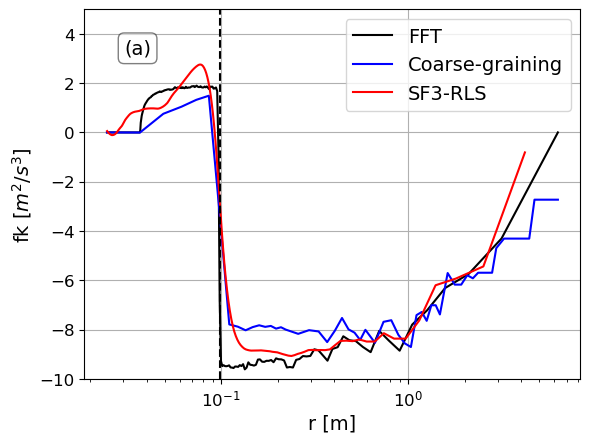

In [7]:
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})
plt.semilogx(1/K1D,fk_fft,color='k',linewidth=1.5,label='FFT')
plt.semilogx(filterscale,fk_cg_e,color='b',linewidth=1.5,label='Coarse-graining')
# plt.fill_between(filterscale,fk_cg_e+Th_e_std,fk_cg_e-Th_e_std,alpha=0.5)
plt.semilogx(1/kf_e*2*np.pi,fk_RLS_e,color='r',linewidth=1.5,label='SF3-RLS')
plt.plot([1/64*2*np.pi,1/64*2*np.pi],[-10,5],color='k',linestyle='--')
plt.legend()
plt.ylim([-10,5])
plt.xlabel(r'r [m]')
plt.ylabel(r'fk [$m^{2}/s^{3}$]')
plt.text(0.08, 0.92, '(a)', transform=plt.gca().transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.grid(True)

/tmp/ipykernel_1330638/571908391.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


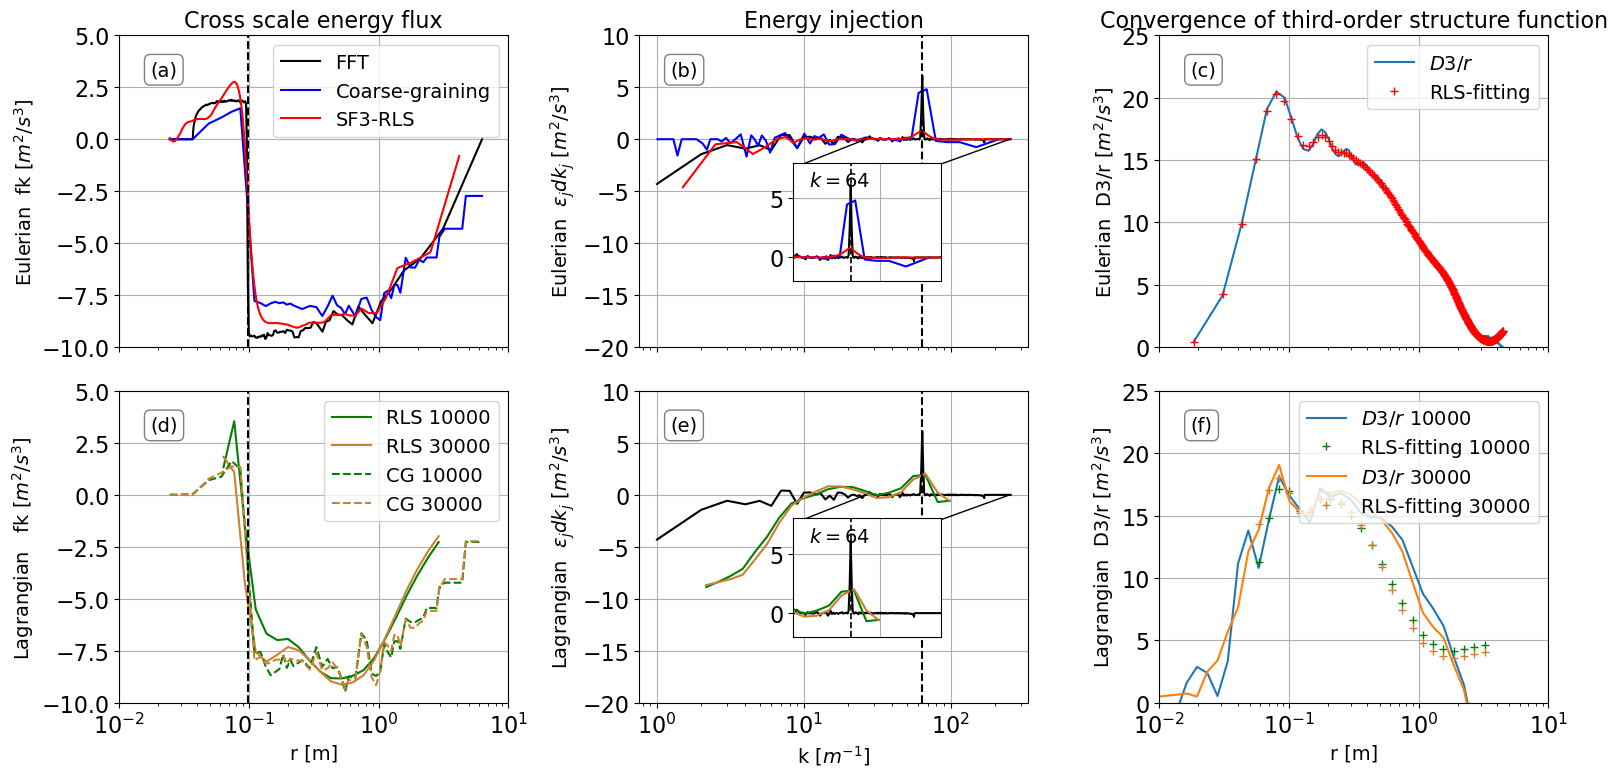

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 设置图形参数
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
})

# 创建2x3子图，并给每个子图分配变量名
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(16, 8))

# 子图1 - 原始图形
ax1.semilogx(1/K1D, fk_fft, color='k', linewidth=1.5, label='FFT')
ax1.semilogx(filterscale, fk_cg_e, color='b', linewidth=1.5, label='Coarse-graining')
ax1.semilogx(1/kf_e*2*np.pi, fk_RLS_e, color='r', linewidth=1.5, label='SF3-RLS')
ax1.plot([1/64 * 2*np.pi, 1/64 * 2*np.pi], [-10, 5], color='k', linestyle='--')
ax1.legend()
ax1.set_ylim([-10, 5])
ax1.set_xlim([1e-2, 1e1])
# ax1.set_xlabel(r'r [m]')
ax1.set_xticklabels('')
ax1.set_ylabel(r'Eulerian  fk [$m^{2}/s^{3}$]')
ax1.text(0.08, 0.92, '(a)', transform=ax1.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax1.grid(True)
ax1.set_title('Cross scale energy flux')

# 子图2
# 
# 
ax2.semilogx(K1D*2*np.pi,eps_fft,color='k', linewidth=1.5)
ax2.semilogx(kf_cgeps*2*np.pi,eps_cg,color='b', linewidth=1.5)
ax2.semilogx(kf_e,eps_e[:-1]*np.abs(np.mean(np.diff(kf_e))),color='r', linewidth=1.5)

ax2.text(0.08, 0.92, '(b)', transform=ax2.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
# ax2.set_xlabel(r'k [$m^{-1}$]')
ax2.set_xticklabels('')
ax2.set_ylim([-20,10])
ax2.set_ylabel(r'Eulerian  $\epsilon_{j}dk_{j}$ [$m^{2}/s^{3}$]')
ax2.grid(True)
ax2.plot(np.array([40.1,13])*2*np.pi,[0,-2.5],linewidth=1.0,color='k')
ax2.plot(np.array([4.2,1.5])*2*np.pi,[0,-2.5],linewidth=1.0,color='k')
ax2.plot([64, 64 ], [-20, 10], color='k', linestyle='--')



ax2_inset = inset_axes(ax2, width="38%", height="38%", loc='lower left',
                      bbox_to_anchor=(0.37, 0.18, 1, 1), bbox_transform=ax2.transAxes)

#
ax2_inset.semilogx(K1D*2*np.pi,eps_fft,color='k', linewidth=1.5)
ax2_inset.semilogx(kf_cgeps*2*np.pi,eps_cg,color='b', linewidth=1.5)
ax2_inset.semilogx(kf_e,eps_e[:-1]*np.abs(np.mean(np.diff(kf_e))),color='r', linewidth=1.5)

ax2_inset.axvline(x=64, color='k', linestyle='--', linewidth=1.2)
ax2_inset.text(64-30, 6, r'$k=64$', fontsize=14, fontweight='bold')
# 
ax2_inset.set_xlim([4.2 * 2*np.pi, 40.6 * 2*np.pi])
ax2_inset.set_ylim([-2, 8])
# ax2_inset.grid(True)
ax2_inset.tick_params(
    axis='both',          # 同时控制x和y轴
    which='both',         # 控制主刻度和次刻度
    bottom=False,         # 移除底部刻度
    top=False,           # 移除顶部刻度
    # left=False,          # 移除左侧刻度
    right=False,         # 移除右侧刻度
    labelbottom=False,   # 移除底部标签
    # labelleft=False,     # 移除左侧标签
    labeltop=False,      # 移除顶部标签
    labelright=False     # 移除右侧标签
)
ax2_inset.grid(True)
ax2.set_title('Energy injection')




# 子图3
# 在这里添加您的第三个图形代码
# 例如: ax3.plot(x_data, y_data, ...)
ax3.semilogx(r_e,sf3_e/r_e,linewidth=1.5,label=r'$D3/r$')
ax3.semilogx(lf_e,Vt_e/lf_e,linewidth=1.5,label=r'RLS-fitting',color='r',marker='+',linestyle='none')
ax3.text(0.08, 0.92, '(c)', transform=ax3.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
# ax3.set_xlabel(r'r [m]')
ax3.set_xticklabels('')
ax3.set_ylabel(r'Eulerian  D3/r [$m^{2}/s^{3}$]')
ax3.grid(True)
ax3.set_title('Convergence of third-order structure function')
ax3.legend()
ax3.set_xlim([1e-2, 1e1])
ax3.set_ylim([0, 25])


ax4.semilogx(1/kf_l*2*np.pi, fk_RLS_1e4_L, color='green', linewidth=1.5, label='RLS 10000')
ax4.semilogx(1/kf_l*2*np.pi, fk_RLS_3e4_L, color=(0.8, 0.5, 0.2), linewidth=1.5, label='RLS 30000')
ax4.semilogx(filterscale_L, fk_cg_1e4_L, color='green', linewidth=1.5, label='CG 10000',linestyle='--')
ax4.semilogx(filterscale_L, fk_cg_3e4_L, color=(0.8, 0.5, 0.2), linewidth=1.5, label='CG 30000',linestyle='--')

ax4.plot([1/64 * 2*np.pi, 1/64 * 2*np.pi], [-10, 5], color='k', linestyle='--')
ax4.text(0.08, 0.92, '(d)', transform=ax4.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax4.set_xlabel(r'r [m]')
ax4.set_ylabel(r'Lagrangian   fk [$m^{2}/s^{3}$]')
ax4.grid(True)
ax4.set_xlim([1e-2, 1e1])
ax4.set_ylim([-10, 5])
ax4.legend()

# 子图5
ax5.semilogx(K1D*2*np.pi,eps_fft,color='k', linewidth=1.5)
ax5.semilogx(kf_l,eps_1e4_L[:-1]*np.abs(np.mean(np.diff(kf_l))),color='g', linewidth=1.5)
ax5.semilogx(kf_l,eps_3e4_L[:-1]*np.abs(np.mean(np.diff(kf_l))),color=(0.8, 0.5, 0.2), linewidth=1.5)

ax5.text(0.08, 0.92, '(e)', transform=ax5.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax5.set_xlabel(r'k [$m^{-1}$]')
ax5.set_ylim([-20,10])
ax5.set_ylabel(r'Lagrangian  $\epsilon_{j}dk_{j}$ [$m^{2}/s^{3}$]')
ax5.grid(True)
ax5.plot(np.array([40.1,13])*2*np.pi,[0,-2.5],linewidth=1.0,color='k')
ax5.plot(np.array([4.2,1.5])*2*np.pi,[0,-2.5],linewidth=1.0,color='k')
ax5.plot([64, 64 ], [-20, 10], color='k', linestyle='--')



ax5_inset = inset_axes(ax5, width="38%", height="38%", loc='lower left',
                      bbox_to_anchor=(0.37, 0.18, 1, 1), bbox_transform=ax5.transAxes)
ax5_inset.semilogx(K1D*2*np.pi,eps_fft,color='k', linewidth=1.5)
ax5_inset.semilogx(kf_l,eps_1e4_L[:-1]*np.abs(np.mean(np.diff(kf_l))),color='g', linewidth=1.5)
ax5_inset.semilogx(kf_l,eps_3e4_L[:-1]*np.abs(np.mean(np.diff(kf_l))),color=(0.8, 0.5, 0.2), linewidth=1.5)

ax5_inset.axvline(x=64, color='k', linestyle='--', linewidth=1.2)
ax5_inset.text(64-30, 6, r'$k=64$', fontsize=14, fontweight='bold')
# 
ax5_inset.set_xlim([4.2 * 2*np.pi, 40.6 * 2*np.pi])
ax5_inset.set_ylim([-2, 8])
# ax2_inset.grid(True)
ax5_inset.tick_params(
    axis='both',          # 同时控制x和y轴
    which='both',         # 控制主刻度和次刻度
    bottom=False,         # 移除底部刻度
    top=False,           # 移除顶部刻度
    # left=False,          # 移除左侧刻度
    right=False,         # 移除右侧刻度
    labelbottom=False,   # 移除底部标签
    # labelleft=False,     # 移除左侧标签
    labeltop=False,      # 移除顶部标签
    labelright=False     # 移除右侧标签
)
ax5_inset.grid(True)
# ax5.set_title('Energy injection')

# 子图6
# 在这里添加您的第六个图形代码
# 
ax6.semilogx(r_1e4,sf3_1e4/r_1e4,linewidth=1.5,label=r'$D3/r$ 10000')
ax6.semilogx(lf_l,Vt_1e4_L/lf_l,linewidth=1.5,label=r'RLS-fitting 10000',color='g',marker='+',linestyle='none')
ax6.semilogx(r_3e4,sf3_3e4/r_3e4,linewidth=1.5,label=r'$D3/r$ 30000')
ax6.semilogx(lf_l,Vt_3e4_L/lf_l,linewidth=1.5,label=r'RLS-fitting 30000',color=(0.8, 0.5, 0.2),marker='+',linestyle='none')
ax6.text(0.08, 0.92, '(f)', transform=ax6.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax6.set_xlabel(r'r [m]')
ax6.set_ylabel(r'Lagrangian  D3/r [$m^{2}/s^{3}$]')
ax6.grid(True)
ax6.set_xlim([1e-2, 1e1])
ax6.set_ylim([0, 25])
ax6.legend(loc=1)
# 调整子图间距
plt.tight_layout()
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/Fig5_HIT2d_fk_eps_fitting.png', dpi=300, bbox_inches='tight')

# 显示图形
plt.show()

/tmp/ipykernel_1415101/1335336006.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


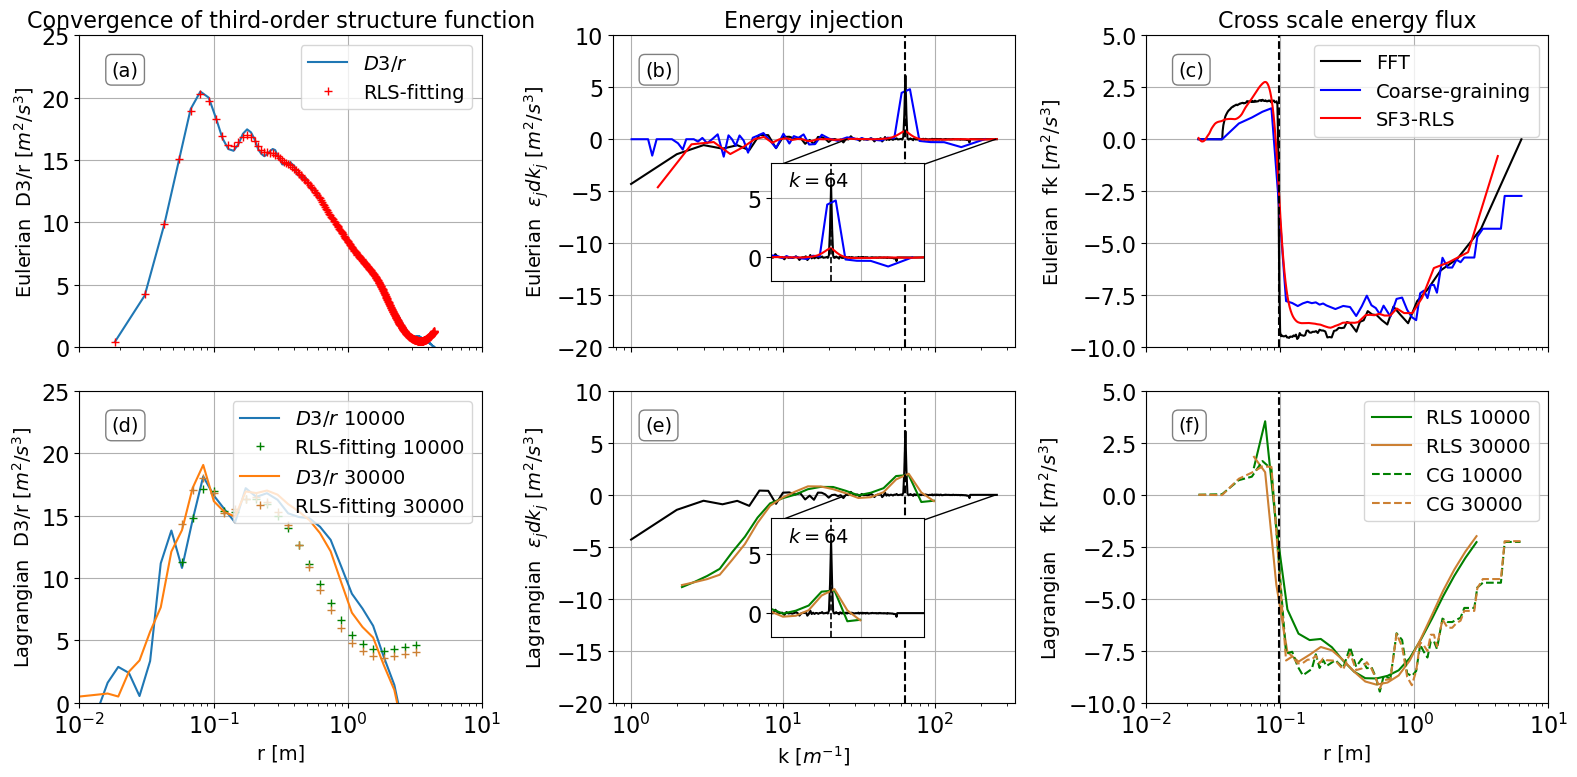

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 设置图形参数
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
})

# 创建2x3子图，交换第一列和第三列
fig, ((ax3, ax2, ax1), (ax6, ax5, ax4)) = plt.subplots(2, 3, figsize=(16, 8))

# 子图3 (原第一列第一个，现在第一列第一个)
ax3.semilogx(r_e,sf3_e/r_e,linewidth=1.5,label=r'$D3/r$')
ax3.semilogx(lf_e,Vt_e/lf_e,linewidth=1.5,label=r'RLS-fitting',color='r',marker='+',linestyle='none')
ax3.text(0.08, 0.92, '(a)', transform=ax3.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax3.set_xticklabels('')
ax3.set_ylabel(r'Eulerian  D3/r [$m^{2}/s^{3}$]')
ax3.grid(True)
ax3.set_title('Convergence of third-order structure function')
ax3.legend()
ax3.set_xlim([1e-2, 1e1])
ax3.set_ylim([0, 25])

# 子图2 (中间列，位置不变)
ax2.semilogx(K1D*2*np.pi,eps_fft,color='k', linewidth=1.5)
ax2.semilogx(kf_cgeps*2*np.pi,eps_cg,color='b', linewidth=1.5)
ax2.semilogx(kf_e,eps_e[:-1]*np.abs(np.mean(np.diff(kf_e))),color='r', linewidth=1.5)
ax2.text(0.08, 0.92, '(b)', transform=ax2.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax2.set_xticklabels('')
ax2.set_ylim([-20,10])
ax2.set_ylabel(r'Eulerian  $\epsilon_{j}dk_{j}$ [$m^{2}/s^{3}$]')
ax2.grid(True)
ax2.plot(np.array([40.1,13])*2*np.pi,[0,-2.5],linewidth=1.0,color='k')
ax2.plot(np.array([4.2,1.5])*2*np.pi,[0,-2.5],linewidth=1.0,color='k')
ax2.plot([64, 64 ], [-20, 10], color='k', linestyle='--')

ax2_inset = inset_axes(ax2, width="38%", height="38%", loc='lower left',
                      bbox_to_anchor=(0.37, 0.18, 1, 1), bbox_transform=ax2.transAxes)
ax2_inset.semilogx(K1D*2*np.pi,eps_fft,color='k', linewidth=1.5)
ax2_inset.semilogx(kf_cgeps*2*np.pi,eps_cg,color='b', linewidth=1.5)
ax2_inset.semilogx(kf_e,eps_e[:-1]*np.abs(np.mean(np.diff(kf_e))),color='r', linewidth=1.5)
ax2_inset.axvline(x=64, color='k', linestyle='--', linewidth=1.2)
ax2_inset.text(64-30, 6, r'$k=64$', fontsize=14, fontweight='bold')
ax2_inset.set_xlim([4.2 * 2*np.pi, 40.6 * 2*np.pi])
ax2_inset.set_ylim([-2, 8])
ax2_inset.tick_params(
    axis='both', which='both',
    bottom=False, top=False, right=False,
    labelbottom=False, labeltop=False, labelright=False
)
ax2_inset.grid(True)
ax2.set_title('Energy injection')

# 子图1 (原第三列第一个，现在第一行第三列)
ax1.semilogx(1/K1D, fk_fft, color='k', linewidth=1.5, label='FFT')
ax1.semilogx(filterscale, fk_cg_e, color='b', linewidth=1.5, label='Coarse-graining')
ax1.semilogx(1/kf_e*2*np.pi, fk_RLS_e, color='r', linewidth=1.5, label='SF3-RLS')
ax1.plot([1/64 * 2*np.pi, 1/64 * 2*np.pi], [-10, 5], color='k', linestyle='--')
ax1.legend()
ax1.set_ylim([-10, 5])
ax1.set_xlim([1e-2, 1e1])
ax1.set_xticklabels('')
ax1.set_ylabel(r'Eulerian  fk [$m^{2}/s^{3}$]')
ax1.text(0.08, 0.92, '(c)', transform=ax1.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax1.grid(True)
ax1.set_title('Cross scale energy flux')

# 子图6 (原第二列第二个，现在第二行第一列)
ax6.semilogx(r_1e4,sf3_1e4/r_1e4,linewidth=1.5,label=r'$D3/r$ 10000')
ax6.semilogx(lf_l,Vt_1e4_L/lf_l,linewidth=1.5,label=r'RLS-fitting 10000',color='g',marker='+',linestyle='none')
ax6.semilogx(r_3e4,sf3_3e4/r_3e4,linewidth=1.5,label=r'$D3/r$ 30000')
ax6.semilogx(lf_l,Vt_3e4_L/lf_l,linewidth=1.5,label=r'RLS-fitting 30000',color=(0.8, 0.5, 0.2),marker='+',linestyle='none')
ax6.text(0.08, 0.92, '(d)', transform=ax6.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax6.set_xlabel(r'r [m]')
ax6.set_ylabel(r'Lagrangian  D3/r [$m^{2}/s^{3}$]')
ax6.grid(True)
ax6.set_xlim([1e-2, 1e1])
ax6.set_ylim([0, 25])
ax6.legend(loc=1)

# 子图5 (中间列，位置不变)
ax5.semilogx(K1D*2*np.pi,eps_fft,color='k', linewidth=1.5)
ax5.semilogx(kf_l,eps_1e4_L[:-1]*np.abs(np.mean(np.diff(kf_l))),color='g', linewidth=1.5)
ax5.semilogx(kf_l,eps_3e4_L[:-1]*np.abs(np.mean(np.diff(kf_l))),color=(0.8, 0.5, 0.2), linewidth=1.5)
ax5.text(0.08, 0.92, '(e)', transform=ax5.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax5.set_xlabel(r'k [$m^{-1}$]')
ax5.set_ylim([-20,10])
ax5.set_ylabel(r'Lagrangian  $\epsilon_{j}dk_{j}$ [$m^{2}/s^{3}$]')
ax5.grid(True)
ax5.plot(np.array([40.1,13])*2*np.pi,[0,-2.5],linewidth=1.0,color='k')
ax5.plot(np.array([4.2,1.5])*2*np.pi,[0,-2.5],linewidth=1.0,color='k')
ax5.plot([64, 64 ], [-20, 10], color='k', linestyle='--')

ax5_inset = inset_axes(ax5, width="38%", height="38%", loc='lower left',
                      bbox_to_anchor=(0.37, 0.18, 1, 1), bbox_transform=ax5.transAxes)
ax5_inset.semilogx(K1D*2*np.pi,eps_fft,color='k', linewidth=1.5)
ax5_inset.semilogx(kf_l,eps_1e4_L[:-1]*np.abs(np.mean(np.diff(kf_l))),color='g', linewidth=1.5)
ax5_inset.semilogx(kf_l,eps_3e4_L[:-1]*np.abs(np.mean(np.diff(kf_l))),color=(0.8, 0.5, 0.2), linewidth=1.5)
ax5_inset.axvline(x=64, color='k', linestyle='--', linewidth=1.2)
ax5_inset.text(64-30, 6, r'$k=64$', fontsize=14, fontweight='bold')
ax5_inset.set_xlim([4.2 * 2*np.pi, 40.6 * 2*np.pi])
ax5_inset.set_ylim([-2, 8])
ax5_inset.tick_params(
    axis='both', which='both',
    bottom=False, top=False, right=False,
    labelbottom=False, labeltop=False, labelright=False
)
ax5_inset.grid(True)

# 子图4 (原第一列第二个，现在第二行第三列)
ax4.semilogx(1/kf_l*2*np.pi, fk_RLS_1e4_L, color='green', linewidth=1.5, label='RLS 10000')
ax4.semilogx(1/kf_l*2*np.pi, fk_RLS_3e4_L, color=(0.8, 0.5, 0.2), linewidth=1.5, label='RLS 30000')
ax4.semilogx(filterscale_L, fk_cg_1e4_L, color='green', linewidth=1.5, label='CG 10000',linestyle='--')
ax4.semilogx(filterscale_L, fk_cg_3e4_L, color=(0.8, 0.5, 0.2), linewidth=1.5, label='CG 30000',linestyle='--')
ax4.plot([1/64 * 2*np.pi, 1/64 * 2*np.pi], [-10, 5], color='k', linestyle='--')
ax4.text(0.08, 0.92, '(f)', transform=ax4.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax4.set_xlabel(r'r [m]')
ax4.set_ylabel(r'Lagrangian   fk [$m^{2}/s^{3}$]')
ax4.grid(True)
ax4.set_xlim([1e-2, 1e1])
ax4.set_ylim([-10, 5])
ax4.legend()

# 调整子图间距
plt.tight_layout()
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/Fig5_HIT2d_fk_eps_fitting.png', dpi=300, bbox_inches='tight')

# 显示图形
plt.show()